# 02 — Player Progression Tracking

## Overview
This notebook tracks how player rankings change over time, identifying distinct
progression archetypes and measuring the speed, consistency and volatility of
player development.

This analysis directly maps to the ITF's requirement of **"tracking player
progression data"** and **"reviewing performance data relating to junior pathway
training and competition testing."**

## Progression metrics defined

To ensure the analysis is structured and reproducible, progression is measured
using three explicitly defined metrics:

| Metric | Definition | Interpretation |
|---|---|---|
| `rank_change` | `rank_start − rank_end` | Positive = improved, Negative = declined |
| `rank_volatility` | Standard deviation of ranking over time | Higher = more unpredictable |
| `improvement_rate` | Slope of ranking trend (linear regression) | Negative slope = improving (rank number falling) |

## Player archetypes
Rather than selecting players subjectively, four archetypes are identified
directly from the data:

- **Rapid risers** — top 5 biggest positive rank_change
- **Declining players** — top 5 biggest negative rank_change
- **Elite consistent** — lowest volatility among top 50 players
- **Breakthrough players** — started outside top 100, ended inside top 50

## Data source
`data/processed/matches_cleaned.csv` — prepared in `00_data_cleaning.ipynb`

## Methodological consideration — match volume and bias

Player progression metrics are influenced by the number of matches played.
Players with more matches have more opportunities to improve their ranking,
while those with fewer matches (e.g., due to injury or scheduling) may show
limited progression.

Rather than normalising metrics by match count, this analysis treats match
volume as an inherent part of player performance:

- **Higher match volume** may indicate consistency, fitness, and deeper
  tournament runs
- **Lower match volume** may reflect injuries, scheduling constraints,
  or performance limitations

Therefore, progression metrics are interpreted alongside `matches_played`
to provide context rather than being explicitly normalised.

Throughout this notebook, `matches_played` is reported alongside all
progression metrics to allow the reader to draw their own conclusions
about the role of match volume.

In [20]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

from scipy import stats

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [3]:
# Loading Data
df = pd.read_csv('../data/processed/matches_cleaned.csv', parse_dates=['tourney_date'])

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df['tourney_date'].min().date()} to {df['tourney_date'].max().date()}")

Dataset loaded: 17654 rows x 21 columns
Date range: 2022-01-03 to 2024-12-18


## Player Progression Feature Engineering

In [5]:
def improvement_rate(ranks):
    if len(ranks) < 3:
        return np.nan
    x = np.arange(len(ranks))
    slope, _, _, _, _ = stats.linregress(x, ranks)
    return round(slope, 4)

# Group by player and calculate all metrics
player_stats = df.groupby('player_name').apply(
    lambda g: pd.Series({
        'matches_played':   len(g),
        'rank_start':       g.loc[g['tourney_date'].idxmin(), 'player_rank'],
        'rank_end':         g.loc[g['tourney_date'].idxmax(), 'player_rank'],
        'career_high':      g['player_rank'].min(),
        'career_low':       g['player_rank'].max(),
        'rank_volatility':  g['player_rank'].std().round(2),
        'improvement_rate': improvement_rate(
                                g.sort_values('tourney_date')['player_rank'].values
                            ),
        'days_in_dataset':  (g['tourney_date'].max() - g['tourney_date'].min()).days
    }), include_groups=False
).reset_index()

# Calculate rank change (positive = improved)
player_stats['rank_change'] = (
    player_stats['rank_start'] - player_stats['rank_end']
).round(2)

# Filter players who appear across at least 6 months AND played at least 10 matches
# Time span ensures meaningful progression trends
# Match count ensures the player was genuinely active
player_stats = player_stats[
    (player_stats['days_in_dataset'] >= 180) &
    (player_stats['matches_played'] >= 10)
].reset_index(drop=True)

print(f"Total players with 6+ months and 10+ matches: {len(player_stats)}")
print(f"\nSample:")
print(player_stats.head(10))

Total players with 6+ months and 10+ matches: 237

Sample:
                   player_name  matches_played  rank_start  rank_end  \
0           Abedallah Shelbayh            14.0       276.0     230.0   
1                  Adam Walton            14.0       176.0      94.0   
2             Adrian Mannarino           168.0        71.0      54.0   
3                 Albert Ramos           102.0        44.0     122.0   
4  Alejandro Davidovich Fokina           147.0        51.0      62.0   
5             Alejandro Tabilo           101.0       139.0      22.0   
6         Aleksandar Kovacevic            48.0       222.0     101.0   
7             Aleksandar Vukic            86.0       156.0      85.0   
8                    Alex Bolt            12.0       137.0     210.0   
9               Alex De Minaur           216.0        34.0       9.0   

   career_high  career_low  rank_volatility  improvement_rate  \
0        185.0       276.0            30.05           -4.8484   
1         89.0    

## Player filtering criteria

To ensure progression metrics are meaningful, players were filtered using
two conditions applied together:

| Filter | Threshold | Reasoning |
|---|---|---|
| Time span | 6+ months (180 days) | Ensures we capture genuine trends rather than short snapshots |
| Matches played | 10+ matches | Ensures the player was genuinely active — not just present in two distant tournaments |

**Players remaining after filtering: 237**

Neither filter alone is sufficient:
- Time span alone allows players who appeared twice over 6 months but barely played
- Match count alone allows players who played 10 matches in a single week
- Combined, they ensure sustained and meaningful activity over time

## Player Archetype Selection

In [6]:
# Identify player archetypes
# Archetype 1 — Rapid risers (biggest positive rank_change)
rapid_risers = player_stats.nlargest(5, 'rank_change')[
    ['player_name', 'rank_start', 'rank_end', 'rank_change',
     'rank_volatility', 'improvement_rate', 'matches_played']
]
print("Rapid risers — top 5 biggest improvements:")
print(rapid_risers.to_string(index=False))

# Archetype 2 — Declining players (biggest negative rank_change)
declining = player_stats.nsmallest(5, 'rank_change')[
    ['player_name', 'rank_start', 'rank_end', 'rank_change',
     'rank_volatility', 'improvement_rate', 'matches_played']
]
print("\nDeclining players — top 5 biggest drops:")
print(declining.to_string(index=False))

# Archetype 3 — Elite consistent (lowest volatility among top 50 players)
elite_consistent = player_stats[
    player_stats['career_high'] <= 50
].nsmallest(5, 'rank_volatility')[
    ['player_name', 'rank_start', 'rank_end', 'rank_change',
     'rank_volatility', 'improvement_rate', 'matches_played']
]
print("\nElite consistent — lowest volatility among players who reached top 50:")
print(elite_consistent.to_string(index=False))

# Archetype 4 — Breakthrough players (started outside top 100, ended inside top 50)
breakthrough = player_stats[
    (player_stats['rank_start'] > 100) &
    (player_stats['rank_end'] <= 50)
][
    ['player_name', 'rank_start', 'rank_end', 'rank_change',
     'rank_volatility', 'improvement_rate', 'matches_played']
].sort_values('rank_change', ascending=False)
print("\nBreakthrough players — started outside top 100, ended inside top 50:")
print(breakthrough.to_string(index=False))

Rapid risers — top 5 biggest improvements:
 player_name  rank_start  rank_end  rank_change  rank_volatility  improvement_rate  matches_played
Learner Tien      1042.0     122.0        920.0           285.86          -59.3741            12.0
Coleman Wong      1032.0     133.0        899.0           358.70          -86.1273            11.0
 Guido Pella      1018.0     203.0        815.0           246.64          -37.4662            21.0
Joao Fonseca       827.0     145.0        682.0           211.84          -30.7135            20.0
Milos Raonic       849.0     177.0        672.0           211.27          -32.8509            19.0

Declining players — top 5 biggest drops:
     player_name  rank_start  rank_end  rank_change  rank_volatility  improvement_rate  matches_played
 Feliciano Lopez       109.0     634.0       -525.0           308.99           45.5779            18.0
  Vasek Pospisil       150.0     610.0       -460.0           153.54           25.2088            13.0
       Yibin

In [7]:
# ── Extract ranking history for selected players ──────────────────────────────

selected_players = {
    'Learner Tien':    'Rapid riser',
    'Oscar Otte':      'Declining',
    'Andrey Rublev':   'Elite consistent',
    'Juncheng Shang':  'Breakthrough'
}

# Get ranking history — one data point per match sorted by date
histories = {}
for player in selected_players:
    history = (
        df[df['player_name'] == player][['tourney_date', 'player_rank']]
        .sort_values('tourney_date')
        .drop_duplicates('tourney_date')
        .reset_index(drop=True)
    )
    histories[player] = history
    print(f"{player} ({selected_players[player]}): {len(history)} data points")
    print(f"  {history['tourney_date'].min().date()} to {history['tourney_date'].max().date()}")
    print(f"  Rank range: {history['player_rank'].min():.0f} to {history['player_rank'].max():.0f}\n")

Learner Tien (Rapid riser): 5 data points
  2022-08-29 to 2024-12-18
  Rank range: 122 to 1042

Oscar Otte (Declining): 41 data points
  2022-01-17 to 2024-06-17
  Rank range: 36 to 474

Andrey Rublev (Elite consistent): 75 data points
  2022-01-17 to 2024-11-11
  Rank range: 5 to 11

Juncheng Shang (Breakthrough): 32 data points
  2022-02-14 to 2024-12-18
  Rank range: 47 to 663



## Player selection — archetype representatives

Players were selected to represent four distinct progression archetypes,
chosen directly from the data rather than subjectively. Each representative
was the most compelling example of their archetype based on the metrics
calculated above.

| Player | Archetype | Rank start | Rank end | Matches | Reasoning |
|---|---|---|---|---|---|
| Learner Tien | Rapid riser | 1042 | 122 | 12 | Largest rank_change relative to matches played — rose nearly 1000 places in just 12 matches. Sparse plot is intentional — it visually communicates the speed of the rise |
| Oscar Otte | Declining | 96 | 474 | 67 | Most matches among declining players — 67 matches ensures the decline is a genuine performance trend rather than injury-driven absence |
| Andrey Rublev | Elite consistent | 6 | 8 | 222 | Lowest ranking volatility (1.30) among all players who reached the top 50 — the definition of elite consistency |
| Juncheng Shang | Breakthrough | 663 | 50 | 62 | Most dramatic breakthrough in the dataset — rose from effectively unranked at tour level to top 50 in 62 matches |

### Note on rapid risers and data sparsity
A true rapid riser by definition plays few matches and climbs quickly.
Sparse data for Learner Tien is therefore expected and correct — it is
a feature of the archetype, not a limitation of the analysis. Replacing
him with a player who has more matches would misrepresent what a rapid
rise actually looks like.

## Player Progression

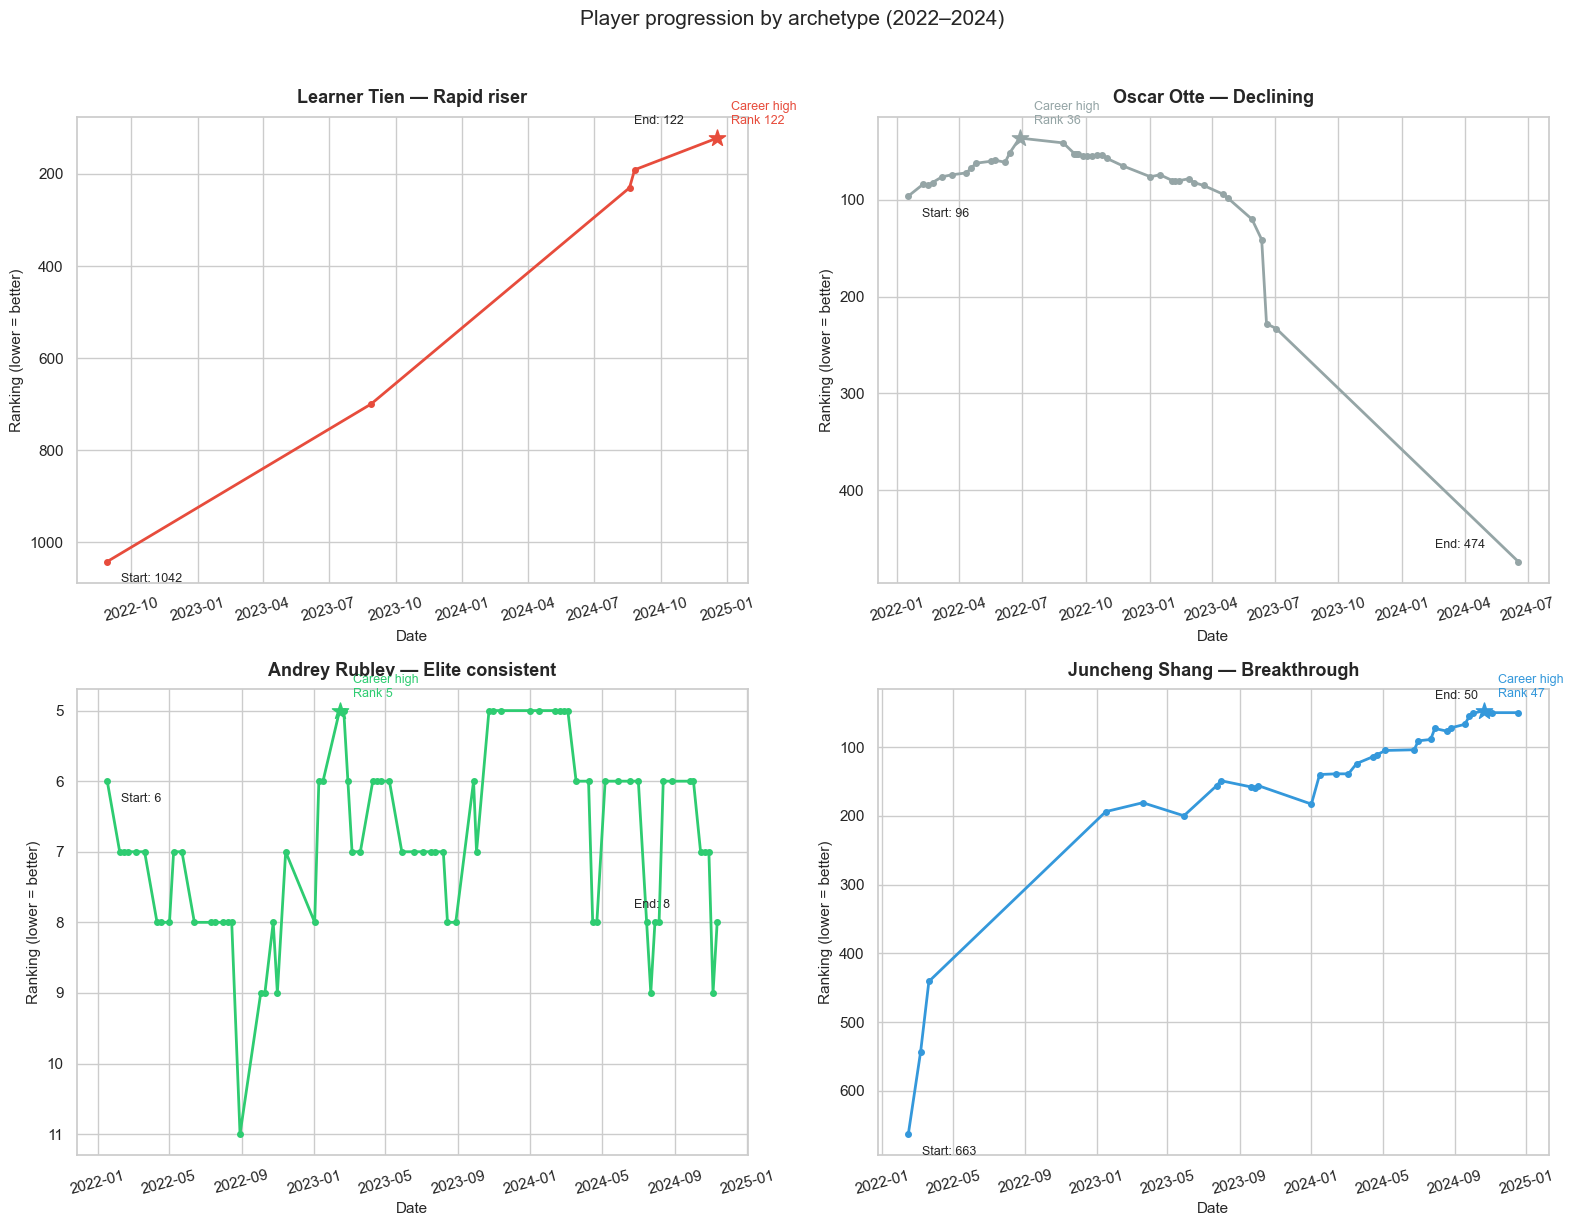

Chart saved to outputs/figures/


In [9]:
# Plot ranking progression for selected players
archetype_colors = {
    'Learner Tien':   '#E74C3C',    # red — rapid riser
    'Oscar Otte':     '#95A5A6',    # gray — declining
    'Andrey Rublev':  '#2ECC71',    # green — elite consistent
    'Juncheng Shang': '#3498DB'     # blue — breakthrough
}

archetype_labels = {
    'Learner Tien':   'Rapid riser',
    'Oscar Otte':     'Declining',
    'Andrey Rublev':  'Elite consistent',
    'Juncheng Shang': 'Breakthrough'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (player, archetype) in enumerate(selected_players.items()):
    ax = axes[idx]
    history = histories[player]
    color = archetype_colors[player]

    # Plot ranking line
    ax.plot(history['tourney_date'], history['player_rank'],
            color=color, linewidth=2, marker='o', markersize=4)

    # Mark career high
    career_high_idx = history['player_rank'].idxmin()
    career_high_date = history.loc[career_high_idx, 'tourney_date']
    career_high_rank = history.loc[career_high_idx, 'player_rank']
    ax.scatter(career_high_date, career_high_rank,
               color=color, s=150, zorder=5, marker='*')
    ax.annotate(f'Career high\nRank {int(career_high_rank)}',
                xy=(career_high_date, career_high_rank),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, color=color)

    # Annotate start and end
    ax.annotate(f'Start: {int(history["player_rank"].iloc[0])}',
                xy=(history['tourney_date'].iloc[0], history['player_rank'].iloc[0]),
                xytext=(10, -15), textcoords='offset points', fontsize=9)
    ax.annotate(f'End: {int(history["player_rank"].iloc[-1])}',
                xy=(history['tourney_date'].iloc[-1], history['player_rank'].iloc[-1]),
                xytext=(-60, 10), textcoords='offset points', fontsize=9)

    # Invert y axis — rank 1 at top
    ax.invert_yaxis()

    ax.set_title(f'{player} — {archetype}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Ranking (lower = better)', fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Player progression by archetype (2022–2024)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/02_player_progression.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Four distinct progression archetypes

Each player tells a visually distinct story that reflects their archetype:

**Learner Tien — Rapid riser**
Rose from rank 1042 to 122 in just 12 matches. The sparse plot is intentional —
it visually communicates the speed and rarity of this kind of rise. True rapid
risers play few matches precisely because they win quickly and climb fast.

**Oscar Otte — Declining**
A clear arc — rose to a career high of rank 36 in early 2022 before a long,
steady decline to 474. With 67 matches this is a genuine performance trend
rather than an injury-driven absence, suggesting a sustained loss of
competitive edge over time.

**Andrey Rublev — Elite consistent**
The tightest band of any player in the dataset — ranking oscillates between
5 and 11 over three years with a volatility of just 1.30. This is what elite
consistency looks like: not a straight line, but an extremely narrow range
regardless of individual match results.

**Juncheng Shang — Breakthrough**
Two distinct phases are visible — a rapid initial rise from 663 to around 200,
a consolidation plateau, then a second surge into the top 50. Breakthrough
players rarely rise in a straight line — they rise, consolidate, then rise again.

In [10]:
# ── Investigate Tien's match history ─────────────────────────────────────────

tien = df[df['player_name'] == 'Learner Tien'][
    ['tourney_date', 'tourney_name', 'round', 'player_rank', 'opponent_rank', 'win']
].sort_values('tourney_date')

print(f"Total Tien matches: {len(tien)}")
print(f"\nFull match history:")
print(tien.to_string(index=False))

Total Tien matches: 12

Full match history:
tourney_date    tourney_name round  player_rank  opponent_rank  win
  2022-08-29         US Open  R128       1042.0           36.0    0
  2023-08-28         US Open  R128        700.0           10.0    0
  2024-08-19   Winston-Salem   R16        230.0           69.0    1
  2024-08-19   Winston-Salem   R32        230.0           49.0    1
  2024-08-19   Winston-Salem   R64        230.0          195.0    1
  2024-08-19   Winston-Salem    QF        230.0          299.0    0
  2024-08-26         US Open  R128        191.0           24.0    0
  2024-12-18 Next Gen Finals    SF        122.0           41.0    1
  2024-12-18 Next Gen Finals    RR        122.0           20.0    1
  2024-12-18 Next Gen Finals    RR        122.0           48.0    1
  2024-12-18 Next Gen Finals     F        122.0          145.0    0
  2024-12-18 Next Gen Finals    RR        122.0          145.0    0


### Data limitation — tournament date vs match date

A known limitation of the Jeff Sackmann ATP dataset is that `tourney_date`
records the **tournament start date** rather than the **individual match date**.
This means all matches within a single tournament are recorded with the same date.

**Impact on progression plots:**
- Players who make deep tournament runs will have multiple matches collapsed
  into a single data point on the plot
- For example, Learner Tien played 4 matches at Winston-Salem and 5 matches
  at the Next Gen Finals — all recorded on the same date in each case
- This affects all players in the dataset — deeper runs = more collapsed points

**Why we did not correct for this:**
Individual match dates are not available in this dataset. Correcting for this
would require a different data source entirely.

**Impact on analysis:**
- Progression plots show ranking snapshots per tournament rather than per match
- Ranking metrics (rank_change, volatility, improvement_rate) are unaffected
  as they use ranking values not match counts
- This limitation should be kept in mind when interpreting the density of
  data points in progression plots

## Volatility vs Improvement Rate

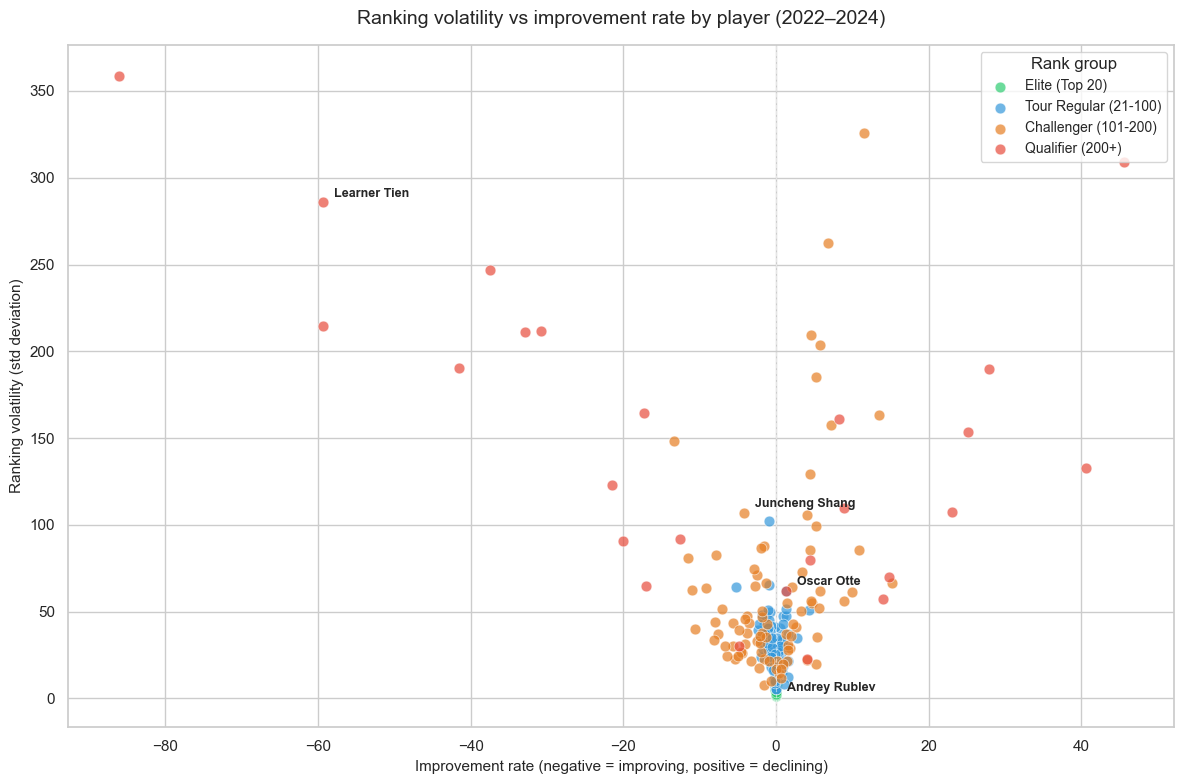

Chart saved to outputs/figures/


In [11]:
# Volatility vs improvement rate scatter plot
# Add rank group to player_stats for colouring
rank_group_map = df.groupby('player_name')['player_rank'].mean().reset_index()
rank_group_map.columns = ['player_name', 'avg_rank']

def assign_group(rank):
    if rank <= 20:
        return 'Elite (Top 20)'
    elif rank <= 100:
        return 'Tour Regular (21-100)'
    elif rank <= 200:
        return 'Challenger (101-200)'
    else:
        return 'Qualifier (200+)'

rank_group_map['rank_group'] = rank_group_map['avg_rank'].apply(assign_group)
player_stats = player_stats.merge(rank_group_map[['player_name', 'rank_group']],
                                   on='player_name', how='left')

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

colors = {
    'Elite (Top 20)':        '#2ECC71',
    'Tour Regular (21-100)': '#3498DB',
    'Challenger (101-200)':  '#E67E22',
    'Qualifier (200+)':      '#E74C3C'
}

for group, color in colors.items():
    subset = player_stats[player_stats['rank_group'] == group]
    ax.scatter(subset['improvement_rate'], subset['rank_volatility'],
               color=color, label=group, alpha=0.7, s=60, edgecolors='white',
               linewidth=0.5)

# Label our four selected players
for player in selected_players:
    row = player_stats[player_stats['player_name'] == player]
    if len(row) > 0:
        ax.annotate(
            player,
            xy=(row['improvement_rate'].values[0], row['rank_volatility'].values[0]),
            xytext=(8, 4), textcoords='offset points',
            fontsize=9, fontweight='bold'
        )

ax.axvline(x=0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Ranking volatility vs improvement rate by player (2022–2024)',
             fontsize=14, pad=15)
ax.set_xlabel('Improvement rate (negative = improving, positive = declining)',
              fontsize=11)
ax.set_ylabel('Ranking volatility (std deviation)', fontsize=11)
ax.legend(title='Rank group', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/02_volatility_vs_improvement.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Volatility vs improvement rate

The scatter plot reveals a clear structure in how players progress:

**The elite cluster (bottom centre)**
Elite and Tour Regular players form a tight cluster near zero on both axes —
low volatility and improvement rates close to zero. These players have found
their level and maintain it with remarkable consistency.

**The volatility-speed trade-off**
Players with the steepest improvement rates (far left) almost always have
the highest volatility. Rapid improvement comes at the cost of consistency —
a player climbing fast is also a player whose ranking is less predictable.

**Our four archetypes in context:**
- **Andrey Rublev** sits closest to the origin — the definition of stable
  elite performance with near-zero volatility and improvement rate
- **Learner Tien** is the most extreme outlier — rapid improvement with
  high volatility, confirming the rapid riser archetype
- **Juncheng Shang** sits in the improving but volatile region — typical
  of breakthrough players still finding their level
- **Oscar Otte** sits just right of zero with moderate volatility —
  a gradual, steady decline

**Qualifiers are scattered everywhere**
Red dots appear across all quadrants — confirming that outside the top 200,
player trajectories are highly unpredictable and non-linear.

## Breakthrough Analysis

In [22]:
# Breakthrough players deep analysis
# Get breakthrough players from player_stats
breakthrough_players = player_stats[
    (player_stats['rank_start'] > 100) &
    (player_stats['rank_end'] <= 50)
].copy().sort_values('rank_change', ascending=False)

print(f"Total breakthrough players: {len(breakthrough_players)}")
print(f"\nBreakthrough player profiles:")
print(breakthrough_players[[
    'player_name', 'rank_start', 'rank_end', 'rank_change',
    'rank_volatility', 'improvement_rate', 'matches_played', 'days_in_dataset'
]].to_string(index=False))

Total breakthrough players: 21

Breakthrough player profiles:
               player_name  rank_start  rank_end  rank_change  rank_volatility  improvement_rate  matches_played  days_in_dataset
            Juncheng Shang       663.0      50.0        613.0           107.02           -4.2006            62.0           1038.0
               Arthur Fils       308.0      20.0        288.0            42.81           -0.9840           109.0            779.0
               Ben Shelton       281.0      21.0        260.0            49.63           -0.8243           123.0            850.0
            Matteo Arnaldi       275.0      38.0        237.0            34.95           -0.9353            92.0            903.0
            Alex Michelsen       250.0      41.0        209.0            42.75           -1.5288            79.0            541.0
Giovanni Mpetshi Perricard       237.0      31.0        206.0            64.39           -5.2565            34.0            518.0
              Jakub Mensik  

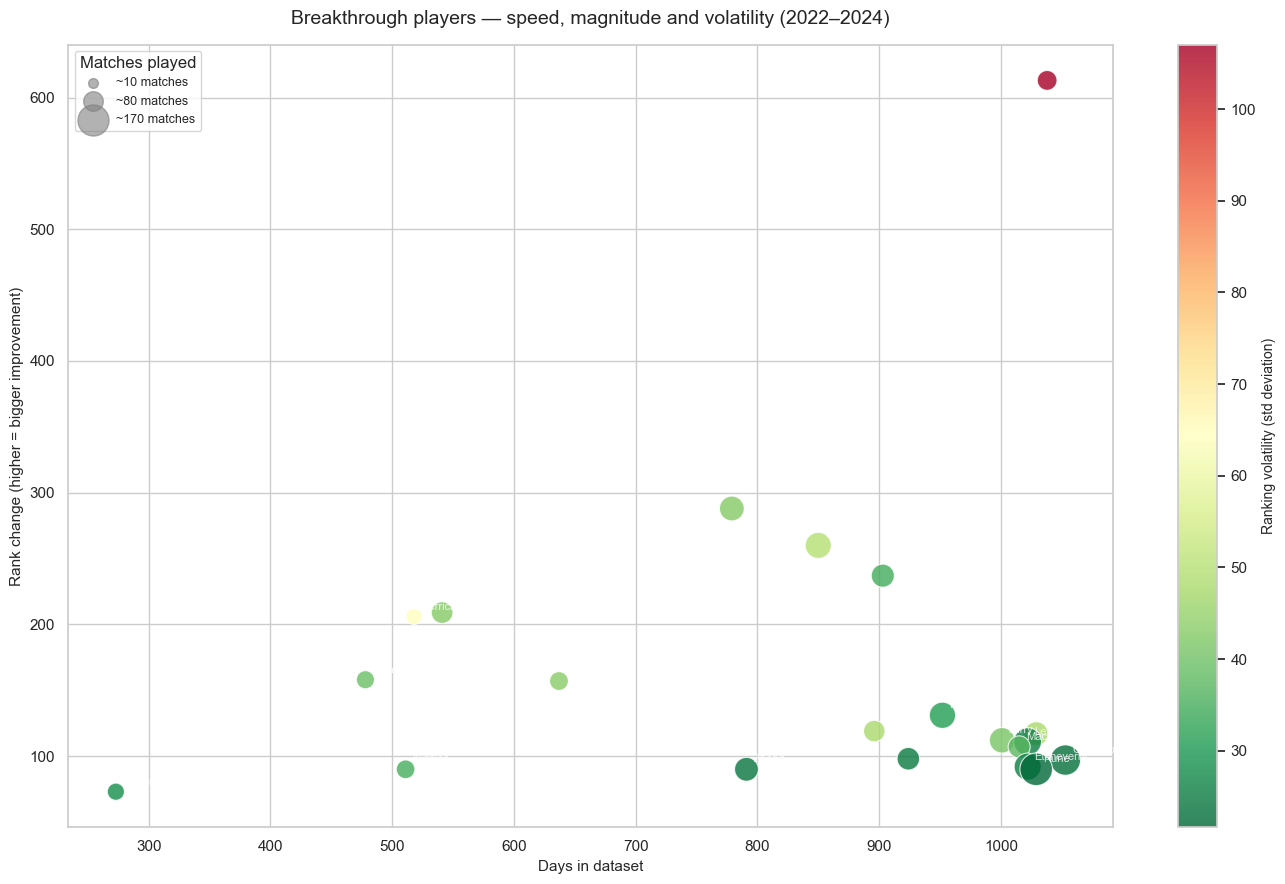

Chart saved to outputs/figures/


In [24]:
# Visualise breakthrough players
fig, ax = plt.subplots(figsize=(14, 9))

# Normalise volatility for colour mapping
norm = plt.Normalize(breakthrough_players['rank_volatility'].min(),
                     breakthrough_players['rank_volatility'].max())
cmap = plt.cm.RdYlGn_r

# Normalise matches played for bubble size
size_scale = (breakthrough_players['matches_played'] /
              breakthrough_players['matches_played'].max() * 500) + 50

scatter = ax.scatter(
    breakthrough_players['days_in_dataset'],
    breakthrough_players['rank_change'],
    c=breakthrough_players['rank_volatility'],
    s=size_scale,
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    edgecolors='white',
    linewidth=0.8
)

# Label each player
for _, row in breakthrough_players.iterrows():
    ax.annotate(
        row['player_name'].split()[-1],  # Last name only to avoid clutter
        xy=(row['days_in_dataset'], row['rank_change']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, color='white', alpha=0.8
    )

# Colourbar for volatility
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Ranking volatility (std deviation)', fontsize=10)

# Size legend
for matches, label in [(50, '~10 matches'), (200, '~80 matches'), (500, '~170 matches')]:
    ax.scatter([], [], s=matches, color='grey', alpha=0.6, label=label)
ax.legend(title='Matches played', fontsize=9, loc='upper left')

ax.set_title('Breakthrough players — speed, magnitude and volatility (2022–2024)',
             fontsize=14, pad=15)
ax.set_xlabel('Days in dataset', fontsize=11)
ax.set_ylabel('Rank change (higher = bigger improvement)', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/02_breakthrough_players.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

## Insight — Breakthrough player analysis

21 players achieved a breakthrough — defined as starting outside the top 100 and ending inside the top 50 — between 2022 and 2024.

### Two broad breakthrough patterns can be observed:

**Pattern 1 — Fast but modest (left side)**
Players who broke through quickly in fewer days but with smaller rank changes. These players were already relatively close to the top 100 and made a focused push into the top 50 within a short time period.

**Pattern 2 — Slow, large and volatile (right side)**
Players who took longer (800+ days) but achieved larger overall ranking improvements. Juncheng Shang stands out as the most extreme case — a highly volatile and dramatic rise from 663 to 50 over an extended period.


### Key findings

- Larger breakthroughs tend to occur over longer time spans, suggesting that substantial ranking gains often require sustained development
- Players with higher match counts often exhibit lower volatility, indicating that consistent match exposure may support more stable progression
- There is no single template for a breakthrough — both rapid climbs and long, turbulent journeys can lead to entry into the top 50


### ITF relevance

These patterns are directly applicable to player development pathways:

- Some players require extended match exposure and gradual improvement to reach elite levels
- Others experience rapid ranking gains that may require careful workload and performance management to sustain performance

Understanding these trajectories can support more personalised coaching, talent identification, and long-term athlete development strategies.

## Summary & Conclusions

This notebook tracked player ranking progression across 237 players with
sufficient data (6+ months and 10+ matches) between 2022 and 2024.

### Key findings

| Finding | Detail |
|---|---|
| Four distinct archetypes exist | Rapid risers, declining players, elite consistent and breakthrough players each show visually distinct progression patterns |
| Rapid improvement comes at a cost | The fastest improving players are almost always the most volatile — there is a clear trade-off between speed and consistency |
| Elite consistency is rare | Only a handful of players (Rublev, Medvedev, Djokovic) maintain volatility below 5 over a sustained period |
| Breakthrough takes time | The largest rank changes (100+ places) almost all occur in players with 800+ days in the dataset |
| Two breakthrough templates exist | Fast focused climbs and slow turbulent journeys both produce top 50 players — there is no single pathway |
| Juncheng Shang is a statistical outlier | His rise from 663 to 50 is the most dramatic in the dataset by a significant margin |

### Limitations
- `tourney_date` records tournament start date not individual match date —
  progression plots show ranking snapshots per tournament rather than per match
- Players with fewer than 10 matches or less than 6 months of data were
  excluded — this removes some interesting short-term stories
- Improvement rate (linear regression slope) assumes a linear trend which
  is rarely the case in practice — it is best interpreted as a directional
  indicator rather than a precise measure

### What comes next
Junior pathway analysis — comparing performance, improvement rate and
volatility across U18, U19–21 and Senior players — is covered in depth
in `03_junior_pathway.ipynb`.

### ITF relevance
Player progression tracking is a core responsibility of the ITF Wheelchair
Tennis Data Scientist role. The archetypes, metrics and visualisations
developed in this notebook provide a reusable framework for tracking
how wheelchair tennis players develop over time — from junior pathway
through to elite competition.